In [1]:
#CONECTANDO A DRIVE (DATASET CARGADO A DRIVE)
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
!pip -q install pyspark


In [ ]:
#Inicialización y configuración del entorno Spark
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("ChicagoCrimesBigData")
         .config("spark.sql.shuffle.partitions", "200")
         .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
spark.conf.set("spark.sql.ansi.enabled", "false")  # MUY IMPORTANTE

In [ ]:
csv_path = "/content/drive/MyDrive/Chicago_Crimes_2001_to_Present.csv"


In [ ]:
#Carga inicial del dataset desde almacenamiento externo
df_raw = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "false")  # archivo muy grande
    .csv(csv_path)
)

print("Filas originales:", df_raw.count())
df_raw.printSchema()

Filas originales: 8422096
root
 |-- ID: string (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: string (nullable = true)
 |-- Domestic: string (nullable = true)
 |-- Beat: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Ward: string (nullable = true)
 |-- Community Area: string (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: string (nullable = true)
 |-- Y Coordinate: string (nullable = true)
 |-- Year: string (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Location: string (nullable = true)



In [ ]:
#Normalización y estandarización de nombres de columnas
from pyspark.sql import functions as F

df = df_raw
for c in df.columns:
    df = df.withColumnRenamed(c, c.strip().replace(" ", "_").replace("-", "_"))

df.columns


['ID',
 'Case_Number',
 'Date',
 'Block',
 'IUCR',
 'Primary_Type',
 'Description',
 'Location_Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community_Area',
 'FBI_Code',
 'X_Coordinate',
 'Y_Coordinate',
 'Year',
 'Updated_On',
 'Latitude',
 'Longitude',
 'Location']

In [ ]:
#Conversión y validación de la variable temporal
from pyspark.sql.types import IntegerType

date_str = F.regexp_replace(F.col("Date").cast("string"), r"\s+", " ")

df = df.withColumn(
    "DateTS",
    F.from_unixtime(
        F.unix_timestamp(date_str, "MM/dd/yyyy hh:mm:ss a")
    ).cast("timestamp")
)

df = df.filter(F.col("DateTS").isNotNull())

df.select("Date", "DateTS").show(5, truncate=False)


+----------------------+-------------------+
|Date                  |DateTS             |
+----------------------+-------------------+
|07/29/2022 03:39:00 AM|2022-07-29 03:39:00|
|01/03/2023 04:44:00 PM|2023-01-03 16:44:00|
|08/10/2020 09:45:00 AM|2020-08-10 09:45:00|
|08/26/2017 10:00:00 AM|2017-08-26 10:00:00|
|09/06/2023 05:00:00 PM|2023-09-06 17:00:00|
+----------------------+-------------------+
only showing top 5 rows


In [ ]:
#ingeniería de variables temporales
df = (
    df.withColumn("year", F.year("DateTS").cast(IntegerType()))
      .withColumn("month", F.month("DateTS").cast(IntegerType()))
      .withColumn("dow", F.dayofweek("DateTS").cast(IntegerType()))
      .withColumn("hour", F.hour("DateTS").cast(IntegerType()))
)



In [2]:
#Selección, depuración y validación de variables relevantes
from pyspark.sql.types import DoubleType

keep_cols = [
    "ID","Case_Number","DateTS",
    "Primary_Type","Description","Location_Description",
    "Arrest","Domestic","Beat","District","Ward","Community_Area",
    "Latitude","Longitude",
    "year","month","dow","hour"
]

df = df.select([c for c in keep_cols if c in df.columns])

# Deduplicar
df = df.dropDuplicates(["ID"])

# Filtros críticos
df = df.filter(
    F.col("Primary_Type").isNotNull() &
    F.col("Arrest").isNotNull() &
    F.col("District").isNotNull()
)

print("Filas limpias:", df.count())
df.show(3, truncate=False)


NameError: name 'df' is not defined

In [ ]:
#Persistencia del dataset en formato columnar Parquet
parquet_path = "/content/drive/MyDrive/chicago_crimes_parquet"

(
    df.write
    .mode("overwrite")
    .partitionBy("year")
    .parquet(parquet_path)
)

dfp = spark.read.parquet(parquet_path)
print("Parquet OK:", dfp.count())


Parquet OK: 8422049


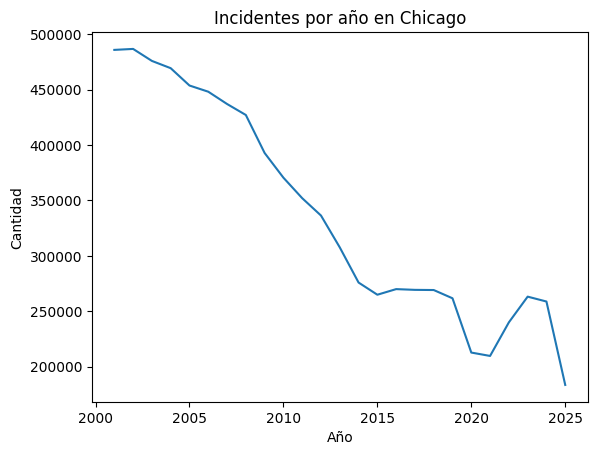

In [ ]:
import matplotlib.pyplot as plt

yearly = dfp.groupBy("year").count().orderBy("year").toPandas()

plt.figure()
plt.plot(yearly["year"], yearly["count"])
plt.title("Incidentes por año en Chicago")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.show()


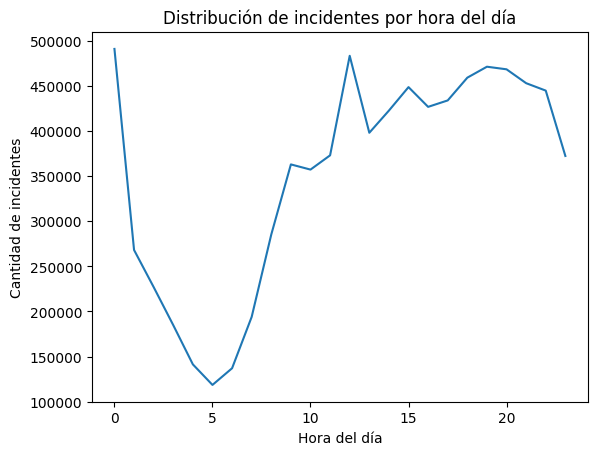

In [ ]:
hour_dist = (
    df.groupBy("hour")
      .count()
      .orderBy("hour")
      .toPandas()
)

plt.figure()
plt.plot(hour_dist["hour"], hour_dist["count"])
plt.title("Distribución de incidentes por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de incidentes")
plt.show()


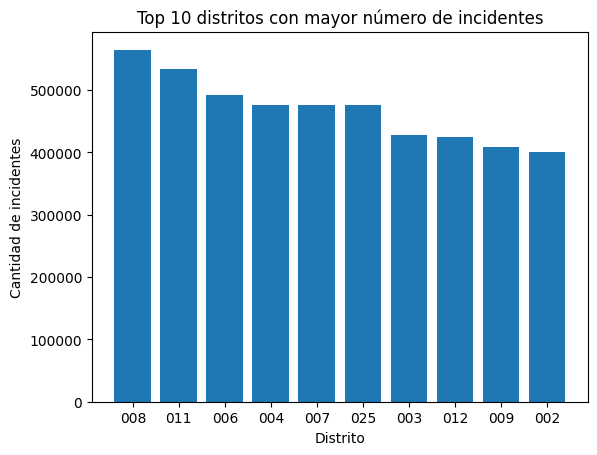

In [ ]:
district_dist = (
    df.groupBy("District")
      .count()
      .orderBy("count", ascending=False)
      .limit(10)
      .toPandas()
)

plt.figure()
plt.bar(district_dist["District"].astype(str), district_dist["count"])
plt.title("Top 10 distritos con mayor número de incidentes")
plt.xlabel("Distrito")
plt.ylabel("Cantidad de incidentes")
plt.show()


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

dfc = dfp.withColumn("label", F.when(F.col("Arrest") == True, 1).otherwise(0))

cat_cols = ["Primary_Type", "Description", "Location_Description", "District"]
num_cols = ["hour", "dow", "month"]

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat_cols]

encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in cat_cols],
    outputCols=[f"{c}_ohe" for c in cat_cols]
)

assembler = VectorAssembler(
    inputCols=[f"{c}_ohe" for c in cat_cols] + num_cols,
    outputCol="features"
)

lr = LogisticRegression(maxIter=30, regParam=0.1)

pipe = Pipeline(stages=indexers + [encoder, assembler, lr])

train, test = dfc.randomSplit([0.8, 0.2], seed=42)

model = pipe.fit(train)
pred = model.transform(test)

auc = BinaryClassificationEvaluator(labelCol="label").evaluate(pred)
f1  = MulticlassClassificationEvaluator(labelCol="label", metricName="f1").evaluate(pred)

print("AUC:", auc)
print("F1 :", f1)


AUC: 0.8969179297820058
F1 : 0.8766624568240606


In [ ]:
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

agg = (
    dfp.groupBy("District","year","month")
       .count()
       .withColumnRenamed("count","crime_count")
)

idx = StringIndexer(inputCol="District", outputCol="District_idx", handleInvalid="keep")
ohe = OneHotEncoder(inputCols=["District_idx"], outputCols=["District_ohe"])
va  = VectorAssembler(inputCols=["District_ohe","year","month"], outputCol="features")

gbr = GBTRegressor(
    labelCol="crime_count",
    maxIter=50,
    maxDepth=6
)

pipe_r = Pipeline(stages=[idx, ohe, va, gbr])

tr, ts = agg.randomSplit([0.8,0.2], seed=42)
m = pipe_r.fit(tr)
p = m.transform(ts)

rmse = RegressionEvaluator(labelCol="crime_count", metricName="rmse").evaluate(p)
mae  = RegressionEvaluator(labelCol="crime_count", metricName="mae").evaluate(p)

print("RMSE:", rmse)
print("MAE :", mae)


RMSE: 97.83360753017251
MAE : 72.43061024420732


In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

df_clu = (
    dfp.withColumn("Latitude", F.col("Latitude").cast(DoubleType()))
       .withColumn("Longitude", F.col("Longitude").cast(DoubleType()))
       .filter(F.col("Latitude").isNotNull() & F.col("Longitude").isNotNull())
)

va = VectorAssembler(
    inputCols=["Latitude","Longitude","hour","dow"],
    outputCol="features"
)

kmeans = KMeans(k=8, seed=42)

pipe_c = Pipeline(stages=[va, kmeans])
m = pipe_c.fit(df_clu)
p = m.transform(df_clu)

sil = ClusteringEvaluator().evaluate(p)
print("Silhouette:", sil)

p.groupBy("prediction").count().orderBy(F.desc("count")).show()


Silhouette: 0.5633509678133254
+----------+-------+
|prediction|  count|
+----------+-------+
|         1|1289305|
|         6|1116332|
|         0|1037163|
|         5|1036334|
|         3|1013607|
|         7| 966751|
|         2| 957756|
|         4| 910957|
+----------+-------+

